In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent.parent
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

df = pd.read_csv(DATA_PROCESSED / "ml_dataset.csv", sep=";")
df.head()

,is_rockstar,sentiment_negative,market_return,AR_event,franchise_gta,impact_label,impact_label_num,event_type_marketing,event_type_negative,event_type_release
0,0,0,-0.012258,-0.001198,0,low,0,False,False,True
1,0,0,0.004073,-0.000318,0,low,0,False,False,True
2,0,1,0.010054,0.003422,0,low,0,False,True,False
3,0,0,0.049396,-0.016937,0,low,0,False,False,True
4,0,1,0.015163,-0.014124,0,medium,1,False,True,False


In [3]:
target = "impact_label_num"

X = df.drop(columns=["impact_label", "impact_label_num"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (72, 8)
y shape: (72,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (54, 8)
Test size: (18, 8)


In [5]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print("F1-score (macro):", round(f1, 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Low","Med","High"],
                yticklabels=["Low","Med","High"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

/files/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
Accuracy: 0.611
F1-score (macro): 0.568

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       1.00      0.25      0.40         4
           2       0.50      0.71      0.59         7

    accuracy                           0.61        18
   macro avg       0.74      0.56      0.57        18
weighted avg       0.69      0.61      0.60        18



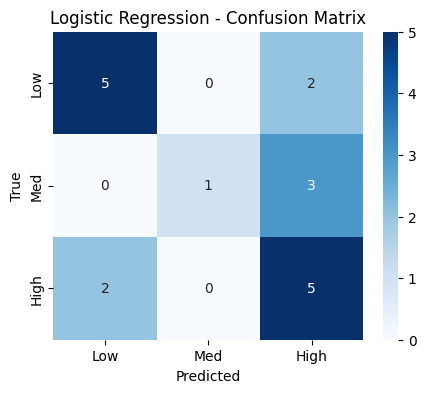

In [6]:
log_reg = LogisticRegression(max_iter=5000, multi_class="multinomial")
log_reg.fit(X_train, y_train)

evaluate_model(log_reg, X_test, y_test, name="Logistic Regression")

=== Random Forest ===
Accuracy: 0.389
F1-score (macro): 0.278

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.71      0.53         7
           1       0.00      0.00      0.00         4
           2       0.33      0.29      0.31         7

    accuracy                           0.39        18
   macro avg       0.25      0.33      0.28        18
weighted avg       0.29      0.39      0.32        18



/files/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/files/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/files/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


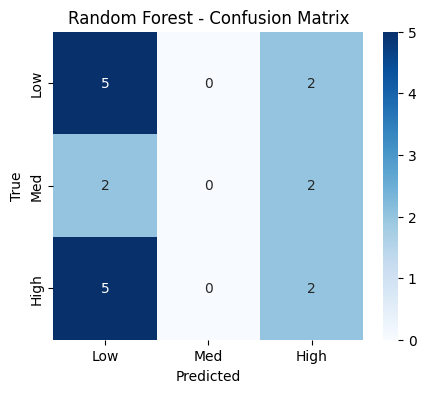

In [7]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, name="Random Forest")

=== Gradient Boosting ===
Accuracy: 0.278
F1-score (macro): 0.208

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.57      0.47         7
           1       0.00      0.00      0.00         4
           2       0.17      0.14      0.15         7

    accuracy                           0.28        18
   macro avg       0.19      0.24      0.21        18
weighted avg       0.22      0.28      0.24        18



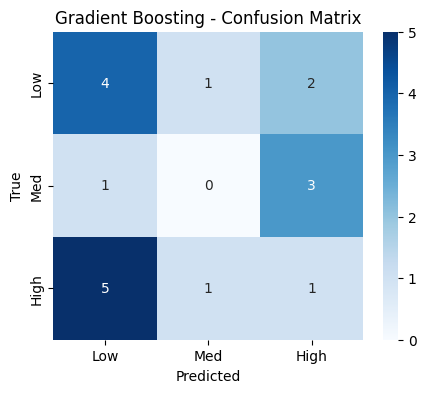

In [8]:
gb = GradientBoostingClassifier(learning_rate=0.05, n_estimators=300, random_state=42)
gb.fit(X_train, y_train)
evaluate_model(gb, X_test, y_test, name="Gradient Boosting")

=== Neural Network (MLP) ===
Accuracy: 0.5
F1-score (macro): 0.364

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.00      0.00      0.00         4
           2       0.50      0.43      0.46         7

    accuracy                           0.50        18
   macro avg       0.33      0.43      0.36        18
weighted avg       0.39      0.50      0.43        18



/files/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/files/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/files/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/files/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill

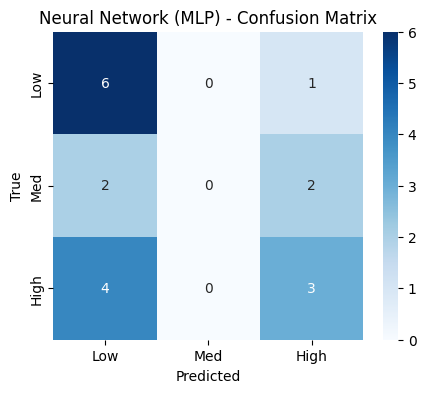

In [9]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

evaluate_model(mlp, X_test, y_test, name="Neural Network (MLP)")

In [10]:
models = {"Logistic Regression": log_reg,
            "Random Forest": rf,
            "Gradient Boosting": gb,
            "Neural Network (MLP)": mlp}

results = []

for name, models in models.items():
    y_pred = models.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    results.append({"Model": name, "Accuracy": acc, "F1-score (macro)": f1})

pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score (macro)"])

,Model,Accuracy,F1-score (macro)
0,Logistic Regression,0.611111,0.567507
1,Random Forest,0.388889,0.278003
2,Gradient Boosting,0.277778,0.208145
3,Neural Network (MLP),0.500000,0.364372


In [11]:
# ✅ Check train vs test accuracy
from sklearn.metrics import accuracy_score

y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy:  {test_acc:.3f}")
print(f"Overfitting risk: {train_acc - test_acc:.3f}")

if train_acc - test_acc > 0.10:
    print("⚠️ WARNING: Possible overfitting")
else:
    print("✅ Good generalization")

Train Accuracy: 1.000
Test Accuracy:  0.278
Overfitting risk: 0.722
⚠️ WARNING: Possible overfitting


In [12]:
# --- Feature Importances from Gradient Boosting ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract importances
importances = gb.feature_importances_
feature_names = X.columns

# Put them in a clean dataframe
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

imp_df.head(15)

,feature,importance
3,AR_event,0.546584
2,market_return,0.276513
0,is_rockstar,0.103786
4,franchise_gta,0.036630
7,event_type_release,0.024800
5,event_type_marketing,0.006932
1,sentiment_negative,0.003216
6,event_type_negative,0.001540


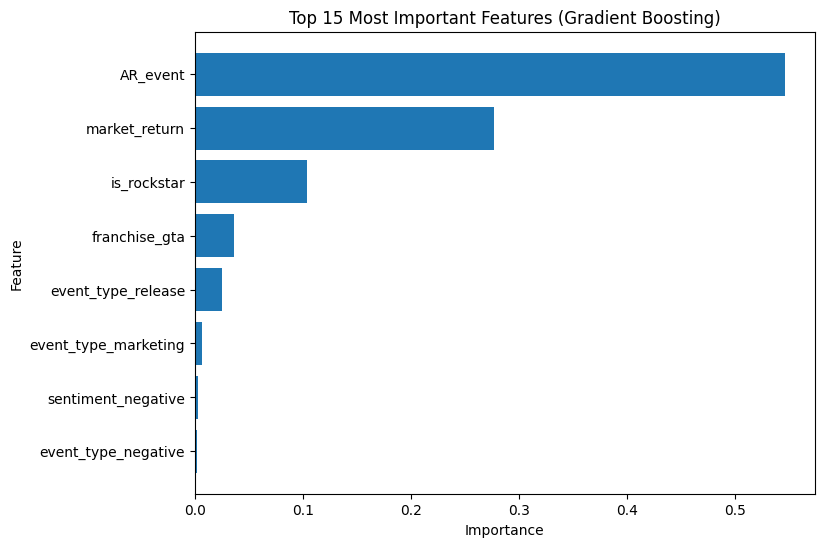

In [13]:
top = imp_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [14]:
print("Class distribution:")
print(df['impact_label_num'].value_counts().sort_index())
print("\nPercentages:")
print(df['impact_label_num'].value_counts(normalize=True).sort_index())

Class distribution:
impact_label_num
0    28
1    17
2    27
Name: count, dtype: int64

Percentages:
impact_label_num
0    0.388889
1    0.236111
2    0.375000
Name: proportion, dtype: float64
